<a href="https://colab.research.google.com/github/pochticeasar/cv/blob/main/task4_style_transfer_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 4: Style Transfer with Diffusion Models

Colab notebook skeleton for `Задание 4`.

Plan:
- use one input image;
- run 4 diffusion models in `image-to-image` mode;
- save the outputs;
- add short architecture notes and a final comparison.

## Models

We use 4 checkpoints/pipelines:

1. `stable-diffusion-v1-5/stable-diffusion-v1-5`
2. `stabilityai/stable-diffusion-xl-refiner-1.0`
3. `stabilityai/sdxl-turbo`
4. `timbrooks/instruct-pix2pix`

Small practical note: for SDXL I use the Refiner checkpoint because the official Diffusers `img2img` examples cover that path directly.

In [3]:
!pip -q install diffusers transformers accelerate safetensors sentencepiece

In [4]:
import gc
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from PIL import Image

from diffusers import (
    AutoPipelineForImage2Image,
    AutoPipelineForText2Image,
    EulerAncestralDiscreteScheduler,
    StableDiffusionInstructPix2PixPipeline,
)

try:
    from google.colab import files
except ImportError:
    files = None

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32
OUTPUT_DIR = Path("task4_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"DEVICE: {DEVICE}")
print(f"DTYPE: {DTYPE}")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


DEVICE: cuda
DTYPE: torch.float16


## Optional: Hugging Face login

If a model asks for license acceptance or auth, uncomment the next cell and paste your token.

In [ ]:
# from huggingface_hub import login
# login()

In [5]:
def seed_everything(seed: int = 42):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def resize_for_model(image: Image.Image, target: int = 512) -> Image.Image:
    image = image.convert("RGB")
    w, h = image.size
    scale = target / min(w, h)
    new_w = int(round(w * scale))
    new_h = int(round(h * scale))
    image = image.resize((new_w, new_h))

    left = (new_w - target) // 2
    top = (new_h - target) // 2
    return image.crop((left, top, left + target, top + target))


def show_triplet(title: str, init_image: Image.Image, result_image: Image.Image):
    plt.figure(figsize=(10, 4))
    plt.suptitle(title)
    plt.subplot(1, 2, 1)
    plt.imshow(init_image)
    plt.axis("off")
    plt.title("Input")

    plt.subplot(1, 2, 2)
    plt.imshow(result_image)
    plt.axis("off")
    plt.title("Output")
    plt.show()


def save_image(image: Image.Image, filename: str):
    path = OUTPUT_DIR / filename
    image.save(path)
    print(f"Saved: {path}")


def cleanup(pipe=None):
    if pipe is not None:
        del pipe
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def prepare_pipe(pipe):
    if DEVICE == "cuda":
        pipe.enable_model_cpu_offload()
    else:
        pipe = pipe.to(DEVICE)
    return pipe


def upload_input_image() -> Image.Image:
    if files is None:
        raise RuntimeError("This helper expects Google Colab.")
    uploaded = files.upload()
    first_name = next(iter(uploaded.keys()))
    image = Image.open(first_name).convert("RGB")
    print(f"Loaded: {first_name}, size={image.size}")
    return image

Saving IMG_20260418_030555_928.jpg to IMG_20260418_030555_928 (1).jpg
Loaded: IMG_20260418_030555_928 (1).jpg, size=(4080, 3072)


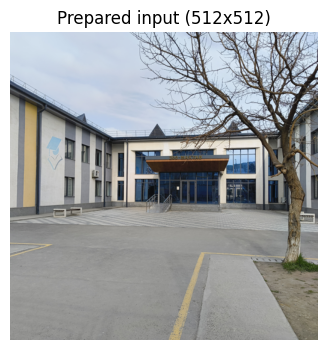

Saved: task4_outputs/input_512.png
Saved: task4_outputs/input_768.png


In [6]:
# Upload one content image. A portrait, city photo, or landscape works well.
init_image_raw = upload_input_image()
init_image_512 = resize_for_model(init_image_raw, target=512)
init_image_768 = resize_for_model(init_image_raw, target=768)

plt.figure(figsize=(4, 4))
plt.imshow(init_image_512)
plt.axis("off")
plt.title("Prepared input (512x512)")
plt.show()

save_image(init_image_512, "input_512.png")
save_image(init_image_768, "input_768.png")

In [7]:
STYLE_PROMPT = "in watercolor style, soft brush strokes, delicate pigments, artistic illustration"
NEGATIVE_PROMPT = "blurry, distorted face, low quality, extra limbs, text, watermark"

INSTRUCT_PROMPT = "Turn this image into a watercolor painting while preserving the main composition"

SEED = 42
seed_everything(SEED)

## Model 1: Stable Diffusion v1.5

Latent diffusion model with a text encoder, VAE, and UNet denoiser. It is lightweight compared to SDXL and usually the easiest baseline to run.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/16 [00:00<?, ?it/s]

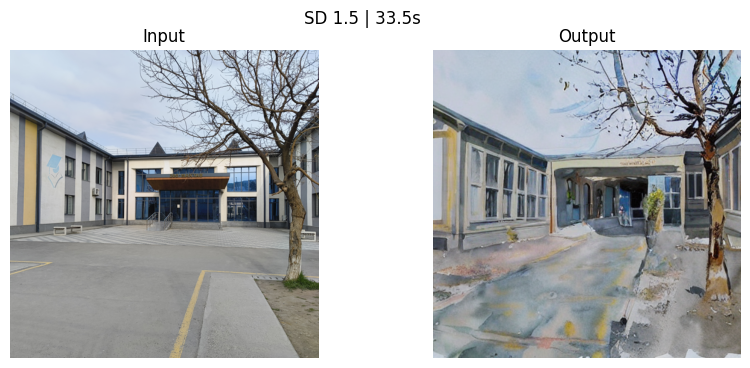

Saved: task4_outputs/sd15_watercolor.png


In [6]:
seed_everything(SEED)
start = time.time()

sd15_kwargs = {
    "torch_dtype": DTYPE,
    "use_safetensors": True,
}
if DTYPE == torch.float16:
    sd15_kwargs["variant"] = "fp16"

pipe_sd15 = AutoPipelineForImage2Image.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5",
    **sd15_kwargs,
)
pipe_sd15 = prepare_pipe(pipe_sd15)

result_sd15 = pipe_sd15(
    prompt=STYLE_PROMPT,
    negative_prompt=NEGATIVE_PROMPT,
    image=init_image_512,
    strength=0.55,
    guidance_scale=7.5,
    num_inference_steps=30,
).images[0]

elapsed = time.time() - start
show_triplet(f"SD 1.5 | {elapsed:.1f}s", init_image_512, result_sd15)
save_image(result_sd15, "sd15_watercolor.png")

## Model 2: SDXL Refiner

This is the higher-capacity SDXL family. In practice it usually produces sharper details and more coherent textures than SD 1.5, though it is heavier and slower.

model_index.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl_img2img.py:896: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


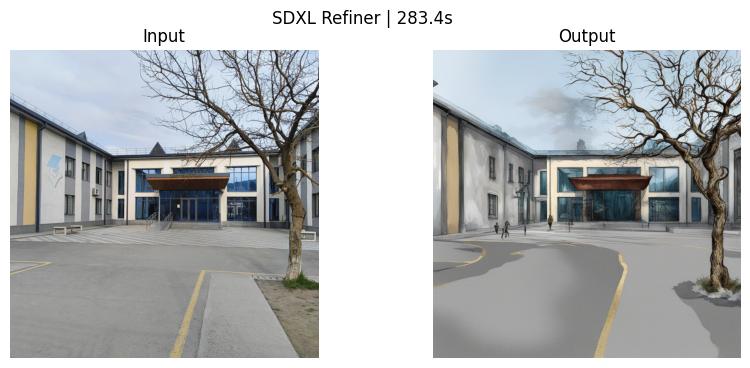

Saved: task4_outputs/sdxl_refiner_watercolor.png


In [7]:
cleanup(pipe_sd15)
seed_everything(SEED)
start = time.time()

sdxl_kwargs = {
    "torch_dtype": DTYPE,
    "use_safetensors": True,
}
if DTYPE == torch.float16:
    sdxl_kwargs["variant"] = "fp16"

pipe_sdxl = AutoPipelineForImage2Image.from_pretrained(
    "stabilityai/stable-diffusion-xl-refiner-1.0",
    **sdxl_kwargs,
)
pipe_sdxl = prepare_pipe(pipe_sdxl)

result_sdxl = pipe_sdxl(
    prompt=STYLE_PROMPT,
    image=init_image_768,
    strength=0.45,
    guidance_scale=6.0,
    num_inference_steps=25,
).images[0]

elapsed = time.time() - start
show_triplet(f"SDXL Refiner | {elapsed:.1f}s", init_image_768, result_sdxl)
save_image(result_sdxl, "sdxl_refiner_watercolor.png")

## Model 3: SDXL Turbo

A distilled SDXL variant designed for very few inference steps. It is the fastest option in this notebook and is useful for demonstrating the quality-speed tradeoff.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl_img2img.py:896: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


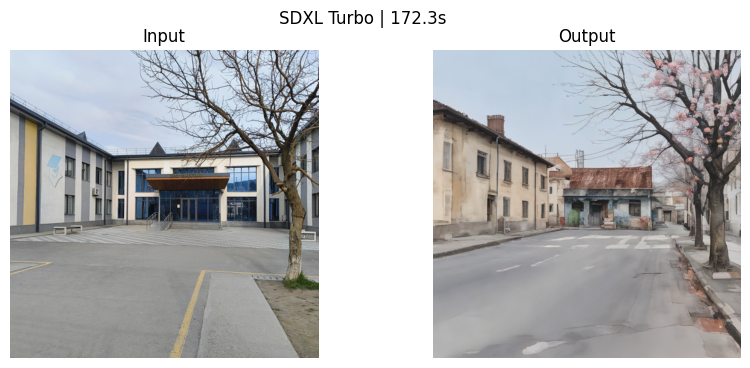

Saved: task4_outputs/sdxl_turbo_watercolor.png


In [10]:
cleanup(globals().get("pipe_sdxl"))
seed_everything(SEED)
start = time.time()

turbo_kwargs = {
    "torch_dtype": DTYPE,
}
if DTYPE == torch.float16:
    turbo_kwargs["variant"] = "fp16"

pipe_turbo_t2i = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sdxl-turbo",
    **turbo_kwargs,
)
if DEVICE == "cuda":
    pipe_turbo_t2i = pipe_turbo_t2i.to(DEVICE)
else:
    pipe_turbo_t2i = pipe_turbo_t2i.to(DEVICE)

pipe_turbo = AutoPipelineForImage2Image.from_pipe(pipe_turbo_t2i)
pipe_turbo = pipe_turbo.to(DEVICE)

result_turbo = pipe_turbo(
    prompt=STYLE_PROMPT,
    image=init_image_512,
    strength=0.5,
    guidance_scale=0.0,
    num_inference_steps=2,
).images[0]

elapsed = time.time() - start
show_triplet(f"SDXL Turbo | {elapsed:.1f}s", init_image_512, result_turbo)
save_image(result_turbo, "sdxl_turbo_watercolor.png")

## Model 4: InstructPix2Pix

This pipeline edits an input image from a natural language instruction. It is useful to show a different style transfer mechanism: not just prompt-conditioned `img2img`, but instruction-based editing.

model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--timbrooks--instruct-pix2pix/snapshots/31519b5cb02a7fd89b906d88731cd4d6a7bbf88d/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/10 [00:00<?, ?it/s]

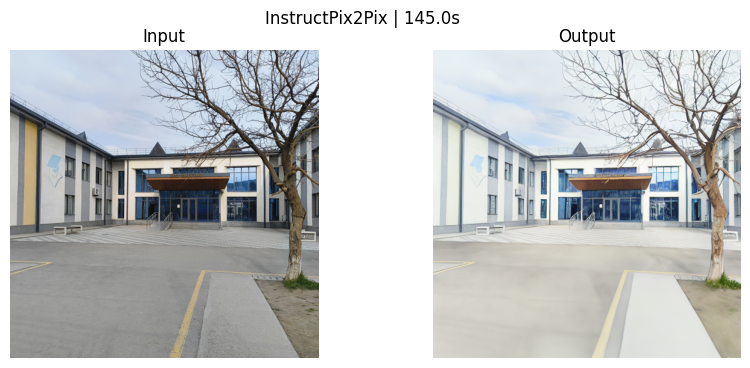

Saved: task4_outputs/instruct_pix2pix_watercolor.png


In [11]:
cleanup(pipe_turbo)
cleanup(pipe_turbo_t2i)
seed_everything(SEED)
start = time.time()

pix_kwargs = {
    "torch_dtype": DTYPE,
    "safety_checker": None,
}

pipe_pix = StableDiffusionInstructPix2PixPipeline.from_pretrained(
    "timbrooks/instruct-pix2pix",
    **pix_kwargs,
)
pipe_pix.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe_pix.scheduler.config)
pipe_pix = prepare_pipe(pipe_pix)

result_pix = pipe_pix(
    prompt=INSTRUCT_PROMPT,
    image=init_image_512,
    num_inference_steps=10,
    image_guidance_scale=1.2,
    guidance_scale=7.0,
).images[0]

elapsed = time.time() - start
show_triplet(f"InstructPix2Pix | {elapsed:.1f}s", init_image_512, result_pix)
save_image(result_pix, "instruct_pix2pix_watercolor.png")

## Final comparison grid

Run this after all four models finish.

NameError: name 'result_sd15' is not defined

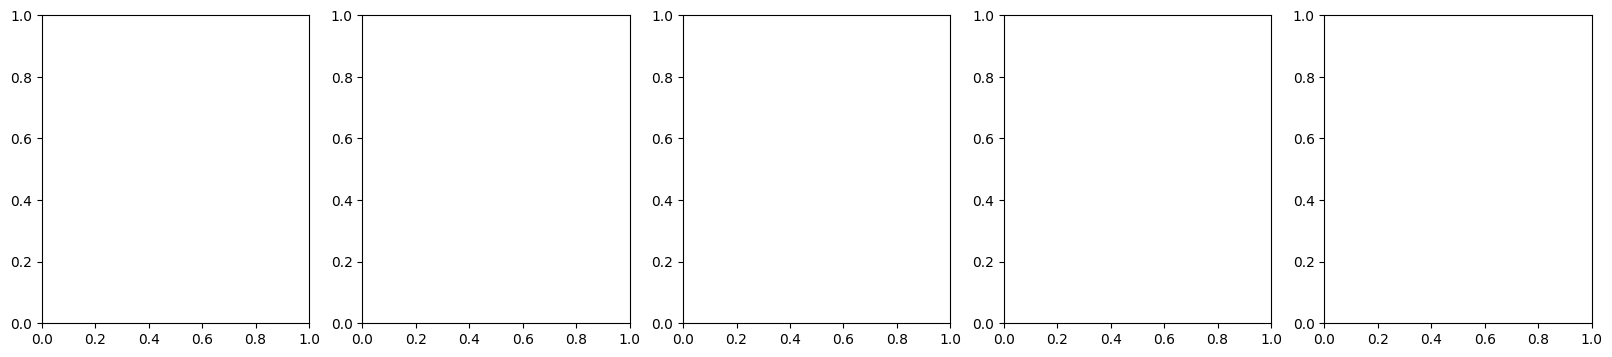

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
items = [
    ("Input", init_image_512),
    ("SD 1.5", result_sd15),
    ("SDXL Refiner", result_sdxl),
    ("SDXL Turbo", result_turbo),
    ("InstructPix2Pix", result_pix),
]

for ax, (title, image) in zip(axes, items):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Short report template

You can paste the following text into the final report and adapt it after you see the outputs.

### Architecture notes

- **Stable Diffusion v1.5** is a latent diffusion model. The text prompt is encoded by a text encoder, the image is represented in a compact latent space by a VAE, and a UNet iteratively denoises the latent representation.
- **SDXL Refiner** belongs to the SDXL family and uses a larger-capacity latent diffusion backbone. In practice it produces more detailed textures and more stable stylization, but requires more compute.
- **SDXL Turbo** is a distilled variant of SDXL designed for generation in a very small number of steps. Its main advantage is speed, though fine details can be weaker than in the full SDXL pipeline.
- **InstructPix2Pix** is an instruction-based image editing model. It takes both an input image and a natural language editing command, making it convenient for controlled style changes.

### Comparison table

| Model | Speed | Style strength | Structure preservation | Overall impression |
|---|---|---|---|---|
| SD 1.5 | medium | fill after run | fill after run | fill after run |
| SDXL Refiner | slow | fill after run | fill after run | fill after run |
| SDXL Turbo | very fast | fill after run | fill after run | fill after run |
| InstructPix2Pix | medium | fill after run | fill after run | fill after run |

### Final conclusion

Example phrasing:

> In this experiment, four diffusion-based image editing models were compared on the task of style transfer. SDXL Refiner produced the most detailed and visually coherent result, SDXL Turbo was the fastest, Stable Diffusion v1.5 gave a strong baseline, and InstructPix2Pix was the most convenient for instruction-driven editing. Therefore, for the best visual quality I would choose SDXL Refiner, while for fast prototyping I would choose SDXL Turbo.

## Sources

- Diffusers image-to-image guide: https://huggingface.co/docs/diffusers/using-diffusers/img2img
- SDXL guide: https://huggingface.co/docs/diffusers/en/using-diffusers/sdxl
- SDXL Turbo guide: https://huggingface.co/docs/diffusers/main/en/using-diffusers/sdxl_turbo
- InstructPix2Pix model card: https://huggingface.co/timbrooks/instruct-pix2pix